## Truss Structures

In [1]:
import sympy as smp

**Demonstrate that the following structure is statically determinate**

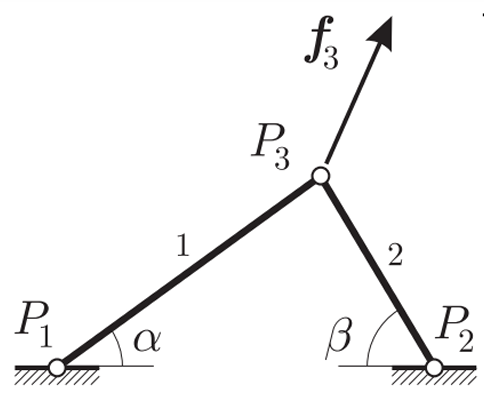

In [2]:
# Symbols
alpha, beta = smp.symbols("alpha, beta", real = True, constant = True, positive = True) # Angles
fx, fy = smp.symbols("f_x, f_y", real = True, constant = True) # External force
R1x, R1y, R2x, R2y = smp.symbols("R_1_x, R_1_y, R_2_x, R_2_y", real = True) # Reaction forces (unknowns)
N13, N23 = smp.symbols("N_1_3, N_2_3", real = True) # Axial forces (unknowns)

# Node 1
N13v = smp.Matrix([N13 * smp.cos(alpha), N13 * smp.sin(alpha)])
R1v = smp.Matrix([R1x, R1y])

# Node 2
N23v = smp.Matrix([- N23 * smp.cos(beta), N23 * smp.sin(beta)])
R2v = smp.Matrix([R2x, R2y])

# Node 3
N31v = - N13v
N32v = - N23v
fv = smp.Matrix([fx, fy])

In [3]:
# Set the sum of the forces equals zero for each node
eq1 = N13v + R1v
eq2 = N23v + R2v
eq3 = N31v + N32v + fv

system = smp.Matrix.vstack(eq1, eq2, eq3)
system

Matrix([
[                 N_1_3*cos(alpha) + R_1_x],
[                 N_1_3*sin(alpha) + R_1_y],
[                 -N_2_3*cos(beta) + R_2_x],
[                  N_2_3*sin(beta) + R_2_y],
[-N_1_3*cos(alpha) + N_2_3*cos(beta) + f_x],
[-N_1_3*sin(alpha) - N_2_3*sin(beta) + f_y]])

In [4]:
# Solution using the solve() SymPy method
sol = smp.solve(system, [R1x, R1y, R2x, R2y, N13, N23])
sol = {key: smp.simplify(value) for key, value in sol.items()}
sol

{N_1_3: (f_x*sin(beta) + f_y*cos(beta))/sin(alpha + beta),
 N_2_3: (-f_x*sin(alpha) + f_y*cos(alpha))/sin(alpha + beta),
 R_1_x: -(f_x*sin(beta) + f_y*cos(beta))*cos(alpha)/sin(alpha + beta),
 R_1_y: -(f_x*sin(beta) + f_y*cos(beta))*sin(alpha)/sin(alpha + beta),
 R_2_x: (-f_x*sin(alpha) + f_y*cos(alpha))*cos(beta)/sin(alpha + beta),
 R_2_y: (f_x*sin(alpha) - f_y*cos(alpha))*sin(beta)/sin(alpha + beta)}

The system has a unique solution

In [5]:
R1v = R1v.subs([(R1x, sol[R1x]),
                (R1y, sol[R1y])])
R1v

Matrix([
[-(f_x*sin(beta) + f_y*cos(beta))*cos(alpha)/sin(alpha + beta)],
[-(f_x*sin(beta) + f_y*cos(beta))*sin(alpha)/sin(alpha + beta)]])

In [6]:
R1v.norm().simplify()

Abs((f_x*sin(beta) + f_y*cos(beta))/sin(alpha + beta))

In [7]:
R2v = R2v.subs([(R2x, sol[R2x]),
                (R2y, sol[R2y])])
R2v

Matrix([
[(-f_x*sin(alpha) + f_y*cos(alpha))*cos(beta)/sin(alpha + beta)],
[ (f_x*sin(alpha) - f_y*cos(alpha))*sin(beta)/sin(alpha + beta)]])

In [8]:
R2v.norm().simplify()

Abs((f_x*sin(alpha) - f_y*cos(alpha))/sin(alpha + beta))

In [9]:
N13v = N13v.subs(N13, sol[N13])
N13v

Matrix([
[(f_x*sin(beta) + f_y*cos(beta))*cos(alpha)/sin(alpha + beta)],
[(f_x*sin(beta) + f_y*cos(beta))*sin(alpha)/sin(alpha + beta)]])

In [10]:
N13v.norm().simplify()

Abs((f_x*sin(beta) + f_y*cos(beta))/sin(alpha + beta))

In [11]:
N23v = N23v.subs(N23, sol[N23])
N23v

Matrix([
[-(-f_x*sin(alpha) + f_y*cos(alpha))*cos(beta)/sin(alpha + beta)],
[ (-f_x*sin(alpha) + f_y*cos(alpha))*sin(beta)/sin(alpha + beta)]])

In [12]:
N23v.norm().simplify()

Abs((f_x*sin(alpha) - f_y*cos(alpha))/sin(alpha + beta))

**Demonstrate that the following structure is unstable**

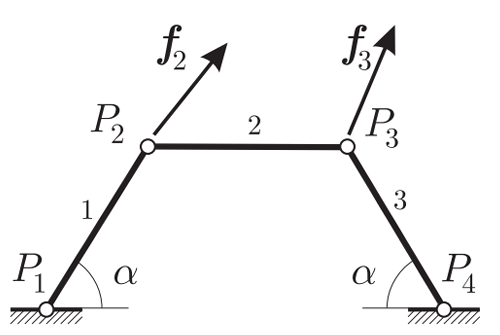

In [13]:
# Symbols
f2x, f2y, f3x, f3y = smp.symbols("f_2_x, f_2_y, f_3_x, f_3_y", real = True, constant = True) # External forces
R1x, R1y, R4x, R4y = smp.symbols("R_1_x, R_1_y, R_4_x, R_4_y", real = True) # Reaction forces (unknowns)
N12, N23, N34 = smp.symbols("N_1_2, N_2_3, N_3_4", real = True) # Axial forces (unknowns)

# Node 1
N12v = smp.Matrix([N12 * smp.cos(alpha), N12 * smp.sin(alpha)])
R1v = smp.Matrix([R1x, R1y])

# Node 2
N23v = smp.Matrix([N23, 0])
N21v = - N12v
f2v = smp.Matrix([f2x, f2y])

# Node 3
N32v = - N23v
N34v = smp.Matrix([N34 * smp.cos(alpha), - N34 * smp.sin(alpha)])
f3v = smp.Matrix([f3x, f3y])

# Node 4
N43v = - N34v
R4v = smp.Matrix([R4x, R4y])

In [14]:
# For each node, the sum of the forces must be equal to zero
eq1 = N12v + R1v
eq2 = f2v + N21v + N23v
eq3 = f3v + N32v + N34v
eq4 = N43v + R4v

system = smp.Matrix.vstack(eq1, eq2, eq3, eq4)
system

Matrix([
[         N_1_2*cos(alpha) + R_1_x],
[         N_1_2*sin(alpha) + R_1_y],
[-N_1_2*cos(alpha) + N_2_3 + f_2_x],
[        -N_1_2*sin(alpha) + f_2_y],
[-N_2_3 + N_3_4*cos(alpha) + f_3_x],
[        -N_3_4*sin(alpha) + f_3_y],
[        -N_3_4*cos(alpha) + R_4_x],
[         N_3_4*sin(alpha) + R_4_y]])

In [15]:
# No solution found using solve() SymPy method
sol = smp.solve(system, [R1x, R1y, R4x, R4y, N12, N23, N34])
sol

[]

In [16]:
# Trying out linear_eq_to_matrix() SymPy method
A, b = smp.linear_eq_to_matrix(system, [R1x, R1y, R4x, R4y, N12, N23, N34])
smp.solve_linear_system(smp.Matrix.hstack(A, b), R1x, R1y, R4x, R4y, N12, N23, N34) # No solution found as well

In [17]:
# Rank of A
A.rank()

7

In [18]:
# Rank of augmented A
smp.Matrix.hstack(A, b).rank()

8

The rank of A is different from that of the augmented A. Therefore, the Rouché–Capelli theorem ensures the system has no solution

**Demonstrate that the following structure is statically indeterminate**

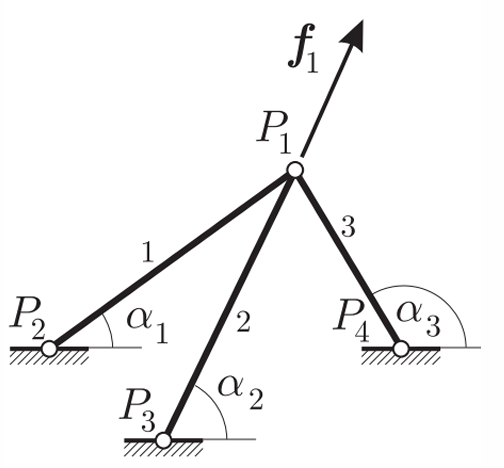

In [19]:
# Symbols
alpha1, alpha2, alpha3 = smp.symbols("alpha_1, alpha_2, alpha_3", real = True, constant = True, positive = True) # Angles
fx, fy = smp.symbols("f_x, f_y", real = True, constant = True) # External force
R2x, R2y, R3x, R3y, R4x, R4y = smp.symbols("R_2_x, R_2_y, R_3_x, R_3_y, R_4_x, R_4_y", real = True) # Reaction forces (unknowns)
N21, N31, N41 = smp.symbols("N_2_1, N_3_1, N_4_1", real = True) # Axial forces (unknowns)

# Node 2
N21v = smp.Matrix([N21 * smp.cos(alpha1), N21 * smp.sin(alpha1)])
R2v = smp.Matrix([R2x, R2y])

# Node 3
N31v = smp.Matrix([N31 * smp.cos(alpha2), N31 * smp.sin(alpha2)])
R3v = smp.Matrix([R3x, R3y])

# Node 4
N41v = smp.Matrix([N41 * smp.cos(alpha3), N41 * smp.sin(alpha3)])
R4v = smp.Matrix([R4x, R4y])

# Node 1
N12v = - N21v
N13v = - N31v
N14v = - N41v
fv = smp.Matrix([fx, fy])

In [20]:
# Sum of the forces for each node equals zero
eq1 = N21v + R2v
eq2 = N31v + R3v
eq3 = N41v + R4v
eq4 = N12v + N13v + N14v + fv

system = smp.Matrix.vstack(eq1, eq2, eq3, eq4)
system

Matrix([
[                                         N_2_1*cos(alpha_1) + R_2_x],
[                                         N_2_1*sin(alpha_1) + R_2_y],
[                                         N_3_1*cos(alpha_2) + R_3_x],
[                                         N_3_1*sin(alpha_2) + R_3_y],
[                                         N_4_1*cos(alpha_3) + R_4_x],
[                                         N_4_1*sin(alpha_3) + R_4_y],
[-N_2_1*cos(alpha_1) - N_3_1*cos(alpha_2) - N_4_1*cos(alpha_3) + f_x],
[-N_2_1*sin(alpha_1) - N_3_1*sin(alpha_2) - N_4_1*sin(alpha_3) + f_y]])

In [21]:
# Solving the system using linear_eq_to_matrix() SymPy method
A, b = smp.linear_eq_to_matrix(system, [R2x, R2y, R3x, R3y, R4x, R4y, N21, N31, N41])
sol = smp.solve_linear_system(smp.Matrix.hstack(A, b), R2x, R2y, R3x, R3y, R4x, R4y, N21, N31, N41)
sol = {key: smp.simplify(value) for key, value in sol.items()}
sol # Infinitely solutions

{R_2_x: (-N_4_1*sin(alpha_2 - alpha_3) + f_x*sin(alpha_2) - f_y*cos(alpha_2))*cos(alpha_1)/sin(alpha_1 - alpha_2),
 R_2_y: (-N_4_1*sin(alpha_2 - alpha_3) + f_x*sin(alpha_2) - f_y*cos(alpha_2))*sin(alpha_1)/sin(alpha_1 - alpha_2),
 R_3_x: (N_4_1*sin(alpha_1 - alpha_3) - f_x*sin(alpha_1) + f_y*cos(alpha_1))*cos(alpha_2)/sin(alpha_1 - alpha_2),
 R_3_y: (N_4_1*sin(alpha_1 - alpha_3) - f_x*sin(alpha_1) + f_y*cos(alpha_1))*sin(alpha_2)/sin(alpha_1 - alpha_2),
 R_4_x: -N_4_1*cos(alpha_3),
 R_4_y: -N_4_1*sin(alpha_3),
 N_2_1: (N_4_1*sin(alpha_2 - alpha_3) - f_x*sin(alpha_2) + f_y*cos(alpha_2))/sin(alpha_1 - alpha_2),
 N_3_1: (-N_4_1*sin(alpha_1 - alpha_3) + f_x*sin(alpha_1) - f_y*cos(alpha_1))/sin(alpha_1 - alpha_2)}

In [22]:
# Rank of A
A.rank()

8

In [23]:
# Rank of augmented A
smp.Matrix.hstack(A, b).rank()

8

Though the rank of A equals that of the augmented matrix, it is less than the number of unknowns. Therefore, the system has infinitely many solutions